# Tema1 - Autovit

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import ast

from sklearn.impute import SimpleImputer

## Incarcare CSV

In [ ]:
df = pd.read_csv('autovit_data/train_cars_listings.csv', low_memory=False)

df_val = pd.read_csv('autovit_data/val_cars_listings.csv')
df.head()


,nume,pret,Oferit de,Are VIN (Serie sasiu),Marca,Model,Versiune,Anul fabricației,Km,Combustibil,...,Electronice si sisteme de asistenta,Siguranta,Norma de poluare,Tara de origine,Data primei inmatriculari,Garantie de la producator pana la,Vehicule electrice,Tuning,Autonomie,Capacitate baterie
0,Opel Astra,3150.0,Firma,NaN,Opel,Astra,NaN,2002,160000.0,Benzina,...,"['Pilot automat', 'Oglinzi exterioare cu regla...","['ABS', 'ESP', 'Airbag sofer', 'Airbag scaun p...",Euro 4,Germania,2002-12-15,NaN,NaN,NaN,NaN,NaN
1,Renault Megane,12495.0,Firma,NaN,Renault,Megane,NaN,2017,159242.0,Diesel,...,"['Pilot automat', 'Senzori parcare fata', 'Sen...","['ABS', 'ESP', 'EBD', 'Franare asistata', 'Sis...",Euro 6,Germania,2017-11-06,NaN,NaN,NaN,NaN,NaN
2,BMW X4 xDrive20d Aut. M Sport,24990.0,Firma,Da,BMW,X4,xDrive20d Aut. M Sport,2016,145000.0,Diesel,...,"['Pilot automat', 'Faruri LED', 'Senzori parca...","['ABS', 'ESP', 'Sistem pre-coliziune lateral',...",Euro 6,NaN,NaN,NaN,['Sistem recuperare energie'],NaN,NaN,NaN
3,Volkswagen Passat 2.0 TDI DSG Highline,22850.0,Firma,Da,Volkswagen,Passat,2.0 TDI DSG Highline,2019,77874.0,Diesel,...,"['Pilot automat adaptiv (distronic)', 'Faruri ...","['ABS', 'ESP', 'Franare asistata', 'Sistem asi...",Euro 6,Romania,2019-12-06,NaN,['Sistem recuperare energie'],NaN,NaN,NaN
4,Volkswagen Golf,7199.0,Firma,Da,Volkswagen,Golf,NaN,2010,230000.0,Benzina,...,"['Pilot automat', 'Servodirectie']","['ABS', 'ESP']",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [91]:
print(f'Setul de date are {df.shape[0]} randuri si {df.shape[1]} coloane')

Setul de date are 18988 randuri si 37 coloane


## Grafice

### GRAFIC 1: Distribuția Variabilei Țintă (Prețul)

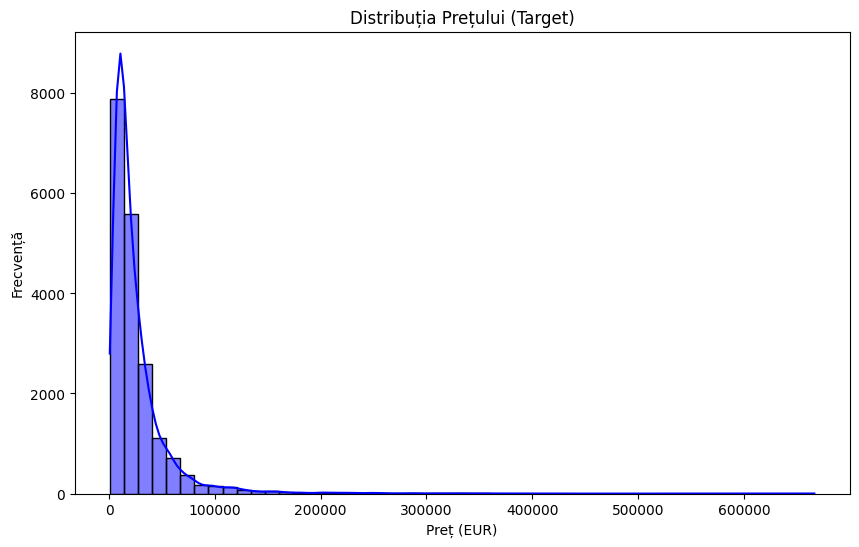

In [92]:
plt.figure(figsize=(10, 6))
sns.histplot(df['pret'], kde=True, bins=50, color='blue')
plt.title('Distribuția Prețului (Target)')
plt.xlabel('Preț (EUR)')
plt.ylabel('Frecvență')
plt.show()

### GRAFIC 2: Analiza datelor lipsa

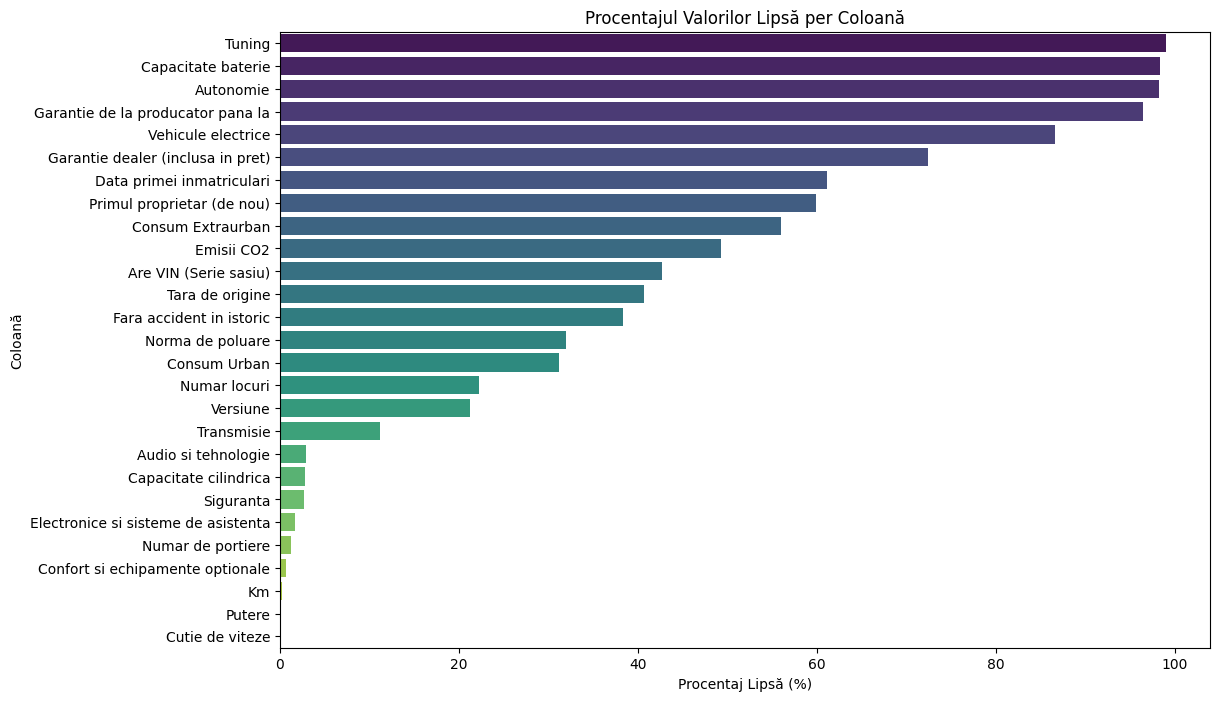

In [93]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
missing_percentage = (missing_values / len(df)) * 100
df_missing = missing_percentage.reset_index()
df_missing.columns = ['coloana', 'procent_lipsa']
plt.figure(figsize=(12, 8))
ax = sns.barplot(x='procent_lipsa', y='coloana', data=df_missing, palette='viridis', hue='coloana', dodge=False)
if ax.get_legend() is not None:
    ax.get_legend().remove()
plt.title('Procentajul Valorilor Lipsă per Coloană')
plt.xlabel('Procentaj Lipsă (%)')
plt.ylabel('Coloană')
plt.show()

### GRAFIC 3: Matricea de Corelație

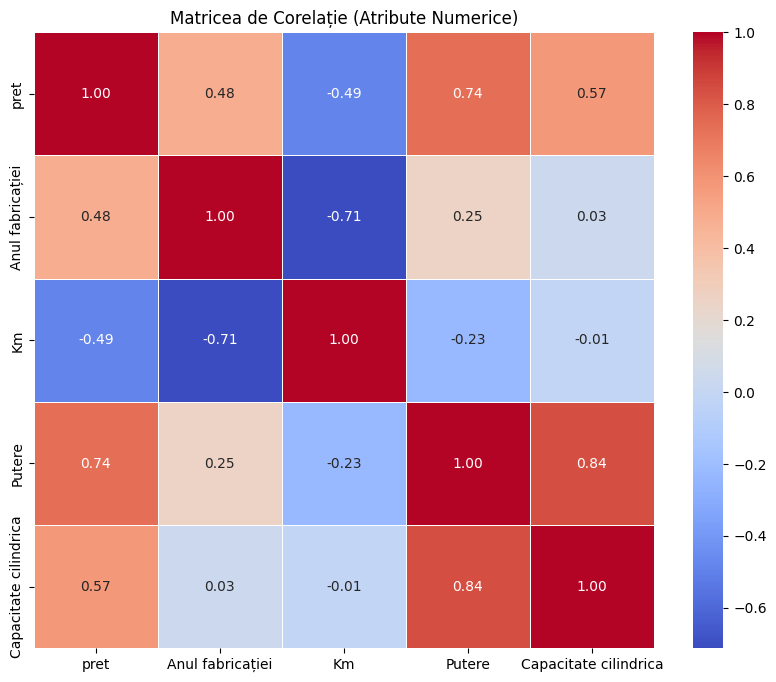

In [94]:
plt.figure(figsize=(10, 8))
numerical_cols = ['pret', 'Anul fabricației', 'Km', 'Putere', 'Capacitate cilindrica']
corr_matrix = df[numerical_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matricea de Corelație (Atribute Numerice)')
plt.show()

Din grafic se observa ca cea mai mare corelatie cu pretul o are puterea vehiculului. Cu cat e mai puternica masina cu atat pretul creste.

De asemenea, cu cat masina are mai multi kilometri, cu atat pretul scade.

### GRAFIC 4: Analiză Categorică (Boxplot)

/var/folders/8l/rrt4tt155_5c99whkyp_zs4h0000gn/T/ipykernel_74915/2763800025.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Combustibil', y='pret', data=df, palette='Set2', order=my_order)


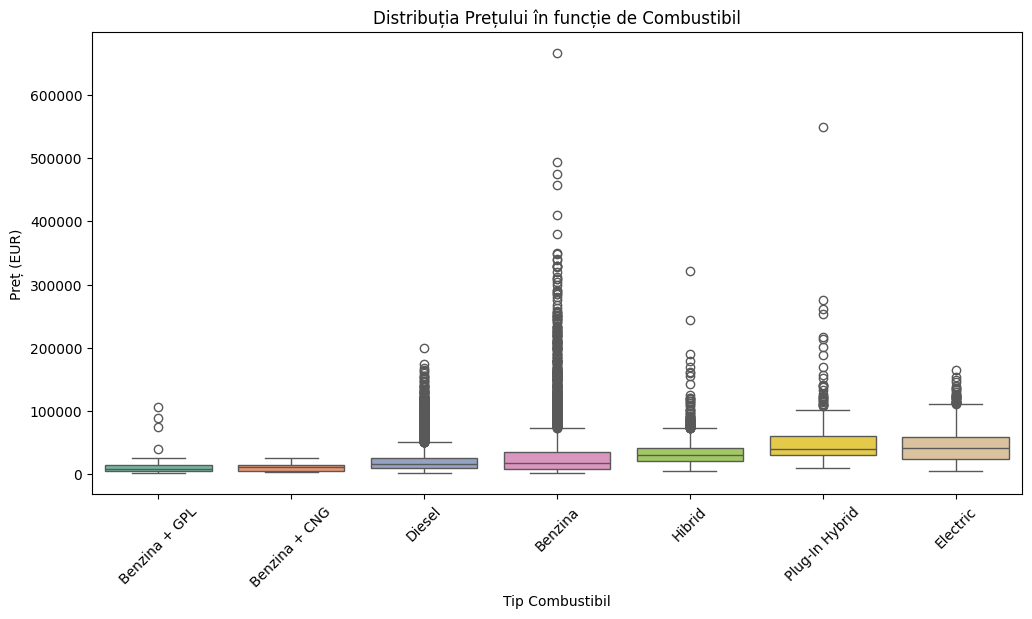

In [95]:
df['Combustibil'] = df['Combustibil'].replace('Hibrid Plug-In', 'Plug-In Hybrid')

my_order = df.groupby(by=["Combustibil"])["pret"].median().sort_values().index

plt.figure(figsize=(12, 6))

sns.boxplot(x='Combustibil', y='pret', data=df, palette='Set2', order=my_order)

plt.title('Distribuția Prețului în funcție de Combustibil')
plt.xlabel('Tip Combustibil')
plt.ylabel('Preț (EUR)')
plt.xticks(rotation=45)

plt.show()

Acest grafic ne lustreaza dispersia preturilor pentru fiecare categorie de combustibil, evidentiind mediana si valorile atipice

Se poate observa ca „Benzina” este cea mai diversa categorie. Aceasta categorie conrine atat cele mai ieftine masini, cat si pe cele mai scumpe. Este categoria cu cea mai mare inegalitate de pret.

## Tratarea si imputarea valorilor lipsa 

### Cazuri speciale pentru setul de date AUTOVIT

Functie auxiliara pt extragerea numerelor din coloane text.
Multe coloane (ex: Putere, Capacitate) contin unitati de masură (CP, cm3, km) amestecate cu numere. 
Voi folosi regex-uri pentru a extrage valorile numerice. 

De asemenea, trebuiesc tratate si vehiculele electrice, unde capacitatea cilindrică nu se aplica

In [96]:
def extract_number(val):
    if pd.isna(val):
        return np.nan
    if isinstance(val, (int, float)):
        return float(val)
    match = re.search(r'(\d+\.?\d*)', str(val))
    if match:
        return float(match.group(1))
    return np.nan

In [97]:
def process_special_cases(df):
    df_clean = df.copy()

    for col in ['Putere', 'Capacitate cilindrica', 'Garantie dealer (inclusa in pret)']:
        df_clean[col] = df_clean[col].apply(extract_number)

    electric_cols = ['Autonomie', 'Capacitate baterie']
    for col in electric_cols:
        df_clean[col] = df_clean[col].apply(extract_number).fillna(0)

    # Crearea coloanelor binare
    df_clean['Este_Electrica'] = df_clean['Combustibil'].apply(
        lambda x: 1 if str(x).lower() in ['electric', 'hibrid', 'hybrid', 'hibrid plug-in'] else 0
    )
    df_clean['Este_second_hand'] = df_clean['Stare'].apply(
        lambda x: 0 if str(x).lower() == 'nou' else 1)

    implicit_bools = ['Primul proprietar (de nou)', 'Fara accident in istoric', 
                      'Are VIN (Serie sasiu)', 'Garantie de la producator pana la']
    
    for col in implicit_bools:
        df_clean[col] = df_clean[col].notna().astype(int)

    return df_clean

df_train_proc = process_special_cases(df)
df_val_proc = process_special_cases(df_val)


Voi transforma `Data primei înmatriculări` intr-un atribut numeric relevant: `Vechime_ani`. 
Vechimea este, intuitiv, unul dintre cei mai importanti predictori ai pretului.

In [98]:
def calculeaza_vechime(df):
    date_series = pd.to_datetime(df['Data primei inmatriculari'], errors='coerce')
    vechime = 2025 - date_series.dt.year
    return vechime.fillna(vechime.median())

df_train_proc['Vechime_ani'] = calculeaza_vechime(df_train_proc)
df_val_proc['Vechime_ani'] = calculeaza_vechime(df_val_proc)

### Imputarea Standard

Folosim strategia medianei pentru coloanele numerice (pentru a nu fi afectati de outlieri) si cea mai frecventa valoare pentru cele categorice.

In [99]:
numeric_cols = ['Anul fabricației', 'Km', 'Putere', 'Capacitate cilindrica']
categorical_cols = ['Marca', 'Model', 'Combustibil', 'Cutie de viteze', 'Tip Caroserie']
numeric_imputer = SimpleImputer(strategy='median')

df_train_proc[numeric_cols] = numeric_imputer.fit_transform(df_train_proc[numeric_cols])
df_val_proc[numeric_cols] = numeric_imputer.transform(df_val_proc[numeric_cols])

cat_imputer = SimpleImputer(strategy='most_frequent')

df_train_proc[categorical_cols] = cat_imputer.fit_transform(df_train_proc[categorical_cols])
df_val_proc[categorical_cols] = cat_imputer.transform(df_val_proc[categorical_cols])

df_train_proc.head()

,nume,pret,Oferit de,Are VIN (Serie sasiu),Marca,Model,Versiune,Anul fabricației,Km,Combustibil,...,Tara de origine,Data primei inmatriculari,Garantie de la producator pana la,Vehicule electrice,Tuning,Autonomie,Capacitate baterie,Este_Electrica,Este_second_hand,Vechime_ani
0,Opel Astra,3150.0,Firma,0,Opel,Astra,NaN,2002.0,160000.0,Benzina,...,Germania,2002-12-15,0,NaN,NaN,0.0,0.0,0,1,23.0
1,Renault Megane,12495.0,Firma,0,Renault,Megane,NaN,2017.0,159242.0,Diesel,...,Germania,2017-11-06,0,NaN,NaN,0.0,0.0,0,1,8.0
2,BMW X4 xDrive20d Aut. M Sport,24990.0,Firma,1,BMW,X4,xDrive20d Aut. M Sport,2016.0,145000.0,Diesel,...,NaN,NaN,0,['Sistem recuperare energie'],NaN,0.0,0.0,0,1,7.0
3,Volkswagen Passat 2.0 TDI DSG Highline,22850.0,Firma,1,Volkswagen,Passat,2.0 TDI DSG Highline,2019.0,77874.0,Diesel,...,Romania,2019-12-06,0,['Sistem recuperare energie'],NaN,0.0,0.0,0,1,6.0
4,Volkswagen Golf,7199.0,Firma,1,Volkswagen,Golf,NaN,2010.0,230000.0,Benzina,...,NaN,NaN,0,NaN,NaN,0.0,0.0,0,1,7.0


### Transformare coloane cu liste in coloane binare

Coloane precum "Dotari" sau "Siguranta" contin liste de string-uri.

Vom extrage cele mai frecvente dotari si le vom transforma in coloane binare, deoarece prezenta anumitor optiuni (ex: Navigație, LED, Trapă) influenteaza pretul.

In [100]:
from collections import Counter
list_cols = ['Audio si tehnologie', 'Confort si echipamente optionale', 
             'Electronice si sisteme de asistenta', 'Siguranta']

def parse_list_column(df, col_name, top_n=10):
    temp_series = df[col_name].fillna("[]").apply(
        lambda x: ast.literal_eval(x) if x.startswith("[") else []
    )
    
    all_items = [item for sublist in temp_series for item in sublist]
    most_common = [item for item, count in Counter(all_items).most_common(top_n)]
    
    for item in most_common:
        clean_name = f"{col_name}_{item.replace(' ', '_').replace('.', '')}"
        df[clean_name] = temp_series.apply(lambda x: 1 if item in x else 0)
    
    return df.drop(columns=[col_name])

for col in list_cols:
    df_train_proc = parse_list_column(df_train_proc, col, top_n=15)
    df_val_proc = parse_list_column(df_val_proc, col, top_n=15)

missing_cols_val = set(df_train_proc.columns) - set(df_val_proc.columns)
for c in missing_cols_val:
    df_val_proc[c] = 0
    
print("Noile dimensiuni Train:", df_train_proc.shape)

cols_to_drop = ['Vehicule electrice', 'Stare', 'Culoare']
df_train_proc = df_train_proc.drop(columns=cols_to_drop)
df_val_proc = df_val_proc[df_train_proc.columns]

Noile dimensiuni Train: (18988, 94)


## Pregătirea Pipeline-ului de Scikit-Learn

### Import-uri

In [101]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from category_encoders import TargetEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import QuantileRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Definire coloane

In [ ]:
target = 'pret'

# Categorice cu multe valori -> Target Encoding
high_card_cols = ['Marca', 'Model', 'Versiune', 'Tara de origine']

# Categorice cu putine valori -> One Hot Encoding
low_card_cols = ['Combustibil', 'Cutie de viteze', 'Tip Caroserie', 'Norma de poluare', 'Transmisie', 'Oferit de']

# Numerice
num_cols = ['Anul fabricației', 'Km', 'Putere', 'Capacitate cilindrica', 'Vechime_ani', 
            'Autonomie', 'Capacitate baterie']

# Adaugam si coloanele binare generate din liste
binary_cols = [c for c in df_train_proc.columns if 'Audio si tehnologie_' in c or 'Siguranta_' in c or 'Confort si echipamente optionale_' in c]
all_numeric = num_cols + binary_cols

### Construiere pipeline

Definirea transformarilor finale:

1.  **Target Encoding** pentru variabile categorice cu cardinalitate mare (ex: Marca, Model), pentru a nu exploda numarul de coloane.
2.  **OneHot Encoding** pentru variabile categorice mici.
3.  **Logaritmarea Targetului (`np.log1p`):** Deoarece distributia prețurilor este asimetrica (vezi grf 1), antrenarea pe logaritmul pretului ajut modelele s performeze mai bine si sa minimizeze eroarea relativa.

In [103]:
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()) 
])

cat_high_pipe = TargetEncoder(handle_missing='value', handle_unknown='value')

cat_low_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, all_numeric),
    ('cat_high', cat_high_pipe, high_card_cols),
    ('cat_low', cat_low_pipe, low_card_cols)
], verbose_feature_names_out=False)


### pregatire X si Y si procesare finala

In [104]:
drop_cols = ['nume', 'Data primei inmatriculari', target]

X_train = df_train_proc.drop(columns=drop_cols, errors='ignore')
y_train = np.log1p(df_train_proc[target])

X_val = df_val_proc.drop(columns=drop_cols, errors='ignore')
y_val = np.log1p(df_val_proc[target])

X_train_final = preprocessor.fit_transform(X_train, y_train)
X_val_final = preprocessor.transform(X_val)

X_train_final = pd.DataFrame(X_train_final, columns=preprocessor.get_feature_names_out())
X_val_final = pd.DataFrame(X_val_final, columns=preprocessor.get_feature_names_out())

print(f"Gata de antrenare! Shape: {X_train_final.shape}")
print("Targetul este logaritmat. La predictie foloseste np.expm1(pred) pentru a reveni la Euro.")

print(X_train_final.head())

Gata de antrenare! Shape: (18988, 93)
Targetul este logaritmat. La predictie foloseste np.expm1(pred) pentru a reveni la Euro.
   Anul fabricației        Km    Putere  Capacitate cilindrica  Vechime_ani  \
0         -3.056224  0.241855 -0.846722              -0.584079     5.628980   
1          0.081692  0.233468 -0.739783              -0.794972     0.212187   
2         -0.127502  0.075886  0.115731               0.027049    -0.148932   
3          0.500081 -0.666836 -0.312026              -0.014514    -0.510052   
4         -1.382669  1.016377 -0.611456              -0.904267    -0.148932   

   Autonomie  Capacitate baterie  Audio si tehnologie_Radio  \
0  -0.125198           -0.099493                   0.384804   
1  -0.125198           -0.099493                   0.384804   
2  -0.125198           -0.099493                   0.384804   
3  -0.125198           -0.099493                   0.384804   
4  -0.125198           -0.099493                   0.384804   

   Audio si tehnolo

## Antrenarea si Optimizarea Modelelor

Functie auxiliara pentru afisarea stats-urilor pentru modele

In [105]:
def show_stats(best_model, y_real, y_pred, X_fin, model_name):
    mae = mean_absolute_error(y_real, y_pred)
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_real, y_pred)

    results = pd.DataFrame({
        'Model': [model_name],
        'MAE': [mae],
        'MSE': [mse],
        'RMSE': [rmse],
        'R2': [r2]
    })
    print(f"\n=== Statistici pentru {model_name} ===")
    display(results)

    comparison = pd.DataFrame({
        'Real': y_real,
        'Predicted': y_pred
    })
    comparison['Error'] = comparison['Real'] - comparison['Predicted']
    print(f"\n=== Primele 5 predicții pentru {model_name} ===")
    display(comparison.head())
    

### Logistic Regression

Nu am inclus acest algoritm pentru ca targetul pe acest set de date este unul continuu nu categoric.

### Random Forest

Voi folosi `RandomizedSearchCV` pentru a cauta cei mai buni hiperparametri. 
Random Forest este robust la outlieri si gestioneaza bine relatiile non-liniare.

In [106]:
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'max_features': ['sqrt', 'log2', 1.0],
    'min_samples_leaf': [1, 2, 4]
}

rf_base = RandomForestRegressor(random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=10, 
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# cautare hiper-parametri
random_search.fit(X_train_final, y_train)

best_rf_model = random_search.best_estimator_
print(f"Cei mai buni parametri pentru Random Forest: {random_search.best_params_}")

y_pred_log = best_rf_model.predict(X_val_final)

y_pred_final = np.expm1(y_pred_log)
y_val_real = np.expm1(y_val)

mae = mean_absolute_error(y_val_real, y_pred_final)
mse = mean_squared_error(y_val_real, y_pred_final)
rmse = np.sqrt(mse)
r2 = r2_score(y_val_real, y_pred_final)

show_stats(best_rf_model, y_val_real, y_pred_final, X_val_final, "Random Forest Regressor")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Cei mai buni parametri pentru Random Forest: {'n_estimators': 300, 'min_samples_leaf': 2, 'max_features': 1.0, 'max_depth': 30}

=== Statistici pentru Random Forest Regressor ===


,Model,MAE,MSE,RMSE,R2
0,Random Forest Regressor,3998.480035,8.426518e+07,9179.606895,0.901869



=== Primele 5 predicții pentru Random Forest Regressor ===


,Real,Predicted,Error
0,69008.0,63873.710638,5134.289362
1,7750.0,7800.512508,-50.512508
2,7999.0,16997.077727,-8998.077727
3,8650.0,12117.601483,-3467.601483
4,18949.0,19264.714958,-315.714958


### Gradient Booster Regressor

In [ ]:
gb_params = {
    'n_estimators': [200, 500],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

gb_search = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_distributions=gb_params,
    n_iter=10,
    scoring="neg_mean_squared_error",
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

print("Antrenare Gradient Boosting (Standard)...")
gb_search.fit(X_train_final, y_train)
print("\nCei mai buni parametri pentru Gradient Boosting:", gb_search.best_params_)
best_gb = gb_search.best_estimator_
y_pred_gb_log = best_gb.predict(X_val_final)
y_pred_gb = np.expm1(y_pred_gb_log)

mae_gb = mean_absolute_error(y_val_real, y_pred_gb)
mse_gb = mean_squared_error(y_val_real, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
r2_gb = r2_score(y_val_real, y_pred_gb)

show_stats(best_gb, y_val_real, y_pred_gb, X_val_final, "Gradient Boosting Regressor")

Antrenare Gradient Boosting (Standard)...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Cei mai buni parametri pentru Gradient Boosting: {'subsample': 1.0, 'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.05}

=== Statistici pentru Gradient Boosting Regressor ===


,Model,MAE,MSE,RMSE,R2
0,Gradient Boosting Regressor,3390.323713,6.127896e+07,7828.087972,0.928638



=== Primele 5 predicții pentru Gradient Boosting Regressor ===


,Real,Predicted,Error
0,69008.0,66697.709991,2310.290009
1,7750.0,7622.664898,127.335102
2,7999.0,14150.878836,-6151.878836
3,8650.0,11834.873981,-3184.873981
4,18949.0,18412.227985,536.772015


### Gradient Boosting Regressor cu Loss='Quantile'

In [108]:
best_gb_params = gb_search.best_params_

print("Antrenare Gradient Boosting Regressor cu Loss='Quantile' (alpha=0.05, 0.50, 0.95)...")

gbr_low = GradientBoostingRegressor(
    loss="quantile",
    alpha=0.05,
    **best_gb_params,
    random_state=42
)
gbr_low.fit(X_train_final, y_train)

gbr_med = GradientBoostingRegressor(
    loss="quantile",
    alpha=0.50,
    **best_gb_params,
    random_state=42
)
gbr_med.fit(X_train_final, y_train)

gbr_high = GradientBoostingRegressor(
    loss="quantile",
    alpha=0.95,
    **best_gb_params,
    random_state=42
)
gbr_high.fit(X_train_final, y_train)

y_pred_low_log = gbr_low.predict(X_val_final)
y_pred_med_log = gbr_med.predict(X_val_final)
y_pred_high_log = gbr_high.predict(X_val_final)

y_pred_low = np.expm1(y_pred_low_log)
y_pred_med = np.expm1(y_pred_med_log)
y_pred_high = np.expm1(y_pred_high_log)


mae_gb_q = mean_absolute_error(y_val_real, y_pred_med)
mse_gb_q = mean_squared_error(y_val_real, y_pred_med)
rmse_gb_q = np.sqrt(mse_gb_q)
r2_gb_q = r2_score(y_val_real, y_pred_med)

show_stats(gbr_med, y_val_real, y_pred_med, X_val_final, "GBR (Quantile - Median)")

quantile_results = pd.DataFrame({
    'Preț Real (EUR)': y_val_real,
    'Cuantila 0.05 (Low)': y_pred_low,
    'Cuantila 0.50 (Median)': y_pred_med,
    'Cuantila 0.95 (High)': y_pred_high
})
print("\n=== Predicții pe Cuantile (GBR) ===\n")
display(quantile_results.head())

Antrenare Gradient Boosting Regressor cu Loss='Quantile' (alpha=0.05, 0.50, 0.95)...

=== Statistici pentru GBR (Quantile - Median) ===


,Model,MAE,MSE,RMSE,R2
0,GBR (Quantile - Median),4707.295597,1.190825e+08,10912.492416,0.861322



=== Primele 5 predicții pentru GBR (Quantile - Median) ===


,Real,Predicted,Error
0,69008.0,64338.673298,4669.326702
1,7750.0,7748.612750,1.387250
2,7999.0,15378.344524,-7379.344524
3,8650.0,14176.366696,-5526.366696
4,18949.0,18134.480052,814.519948



=== Predicții pe Cuantile (GBR) ===



,Preț Real (EUR),Cuantila 0.05 (Low),Cuantila 0.50 (Median),Cuantila 0.95 (High)
0,69008.0,50113.095708,64338.673298,67700.692823
1,7750.0,6491.612844,7748.612750,9582.151991
2,7999.0,11278.455570,15378.344524,15975.989983
3,8650.0,8689.839845,14176.366696,13805.238177
4,18949.0,18001.397871,18134.480052,29439.569965


### QuantileRegressor

Am comentat codul pentru acest algoritm pentru ca dureaza foarte mult sa ruleze pe laptop-ul meu.

In [ ]:
# qr_model = QuantileRegressor(quantile=0.5, alpha=0.01, solver='highs')

# print("Antrenare QuantileRegressor (Median - 0.5)...")
# qr_model.fit(X_train_final, y_train)

# y_pred_qr_log = qr_model.predict(X_val_final)
# y_pred_qr = np.expm1(y_pred_qr_log)

# show_stats(qr_model, y_val_real, y_pred_qr, X_val_final, "Quantile Regressor (Linear - Median)")

Antrenare QuantileRegressor (Median - 0.5)...


KeyboardInterrupt: 

### SVR

In [112]:
svr_params = {
    'C': [1, 10, 100],
    "gamma": ["scale", "auto"],
    'kernel': ["rbf", "linear", "poly"]
}
scoring_svr = {
    "MSE": "neg_mean_squared_error",
    "MAE": "neg_mean_absolute_error",
    "R2": "r2",
}

svr_search = RandomizedSearchCV(
    estimator=SVR(),
    param_distributions=svr_params,
    n_iter=4, 
    scoring=scoring_svr,
    refit="MSE",
    cv=3,
    n_jobs=-1,
    random_state=42
)

svr_search.fit(X_train_final, y_train)

best_svr = svr_search.best_estimator_
print(f"Cei mai buni parametri pentru SVR: {svr_search.best_params_}")
y_pred_svr_log = best_svr.predict(X_val_final)
y_pred_svr = np.expm1(y_pred_svr_log)

mae_svr = mean_absolute_error(y_val_real, y_pred_svr)
mse_svr = mean_squared_error(y_val_real, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)
r2_svr = r2_score(y_val_real, y_pred_svr)

show_stats(best_svr, y_val_real, y_pred_svr, X_val_final, "Support Vector Regressor")

Cei mai buni parametri pentru SVR: {'kernel': 'rbf', 'gamma': 'scale', 'C': 1}

=== Statistici pentru Support Vector Regressor ===


,Model,MAE,MSE,RMSE,R2
0,Support Vector Regressor,3920.392724,1.148508e+08,10716.845606,0.866251



=== Primele 5 predicții pentru Support Vector Regressor ===


,Real,Predicted,Error
0,69008.0,59076.321173,9931.678827
1,7750.0,7334.770377,415.229623
2,7999.0,10460.736651,-2461.736651
3,8650.0,7933.207021,716.792979
4,18949.0,21293.406572,-2344.406572


## Final Stats

/var/folders/8l/rrt4tt155_5c99whkyp_zs4h0000gn/T/ipykernel_74915/1506966683.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='magma')


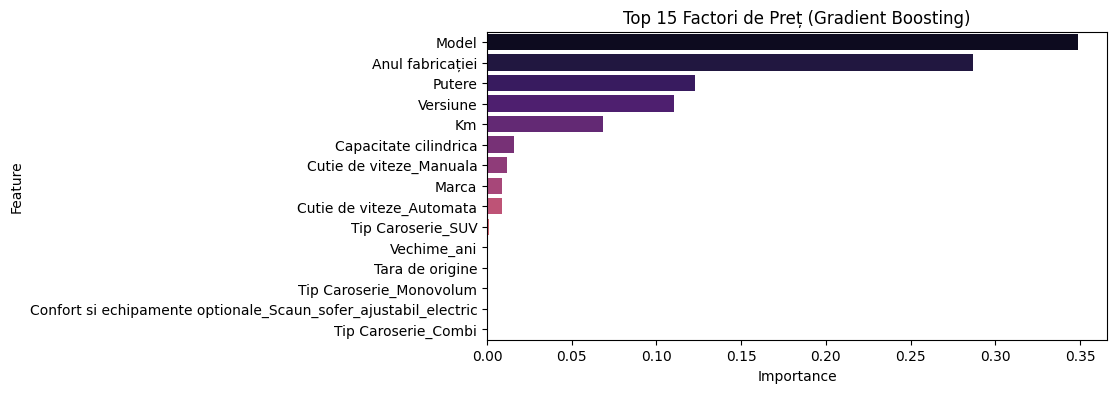


============= CLASAMENT FINAL =============


,Model,R2 Score (Mai mare e mai bun),MAE (Eroare - Mai mic e mai bun),RMSE
0,Gradient Boosting (Standard),0.928638,3390.323713,7828.087972
1,Random Forest,0.901869,3998.480035,9179.606895
2,SVR,0.894789,3708.032868,9504.988944
3,GBR (Quantile - Median),0.861322,4707.295597,10912.492416


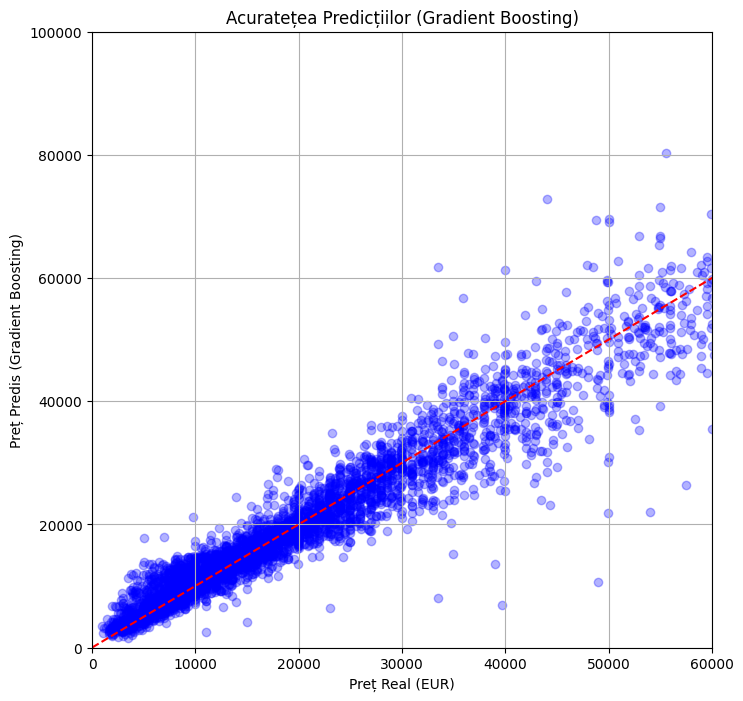

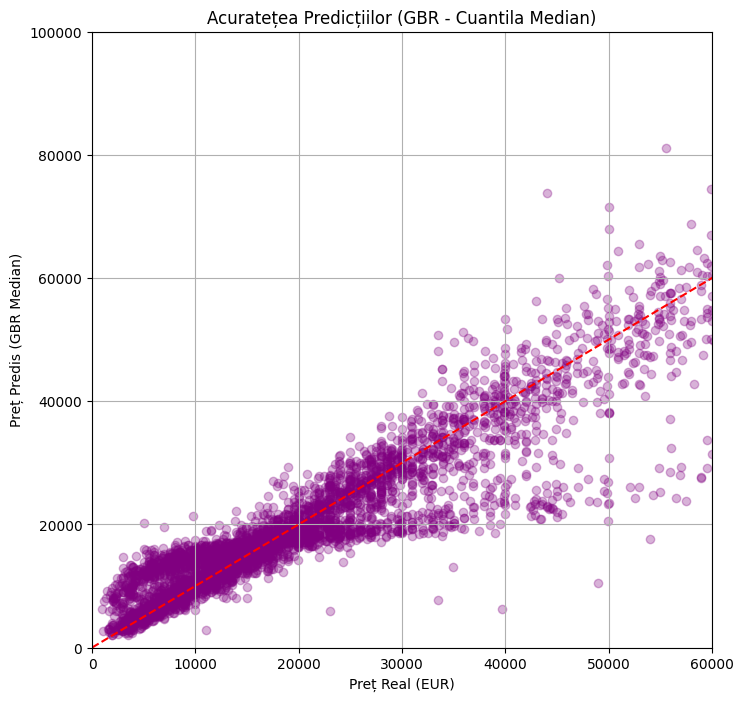

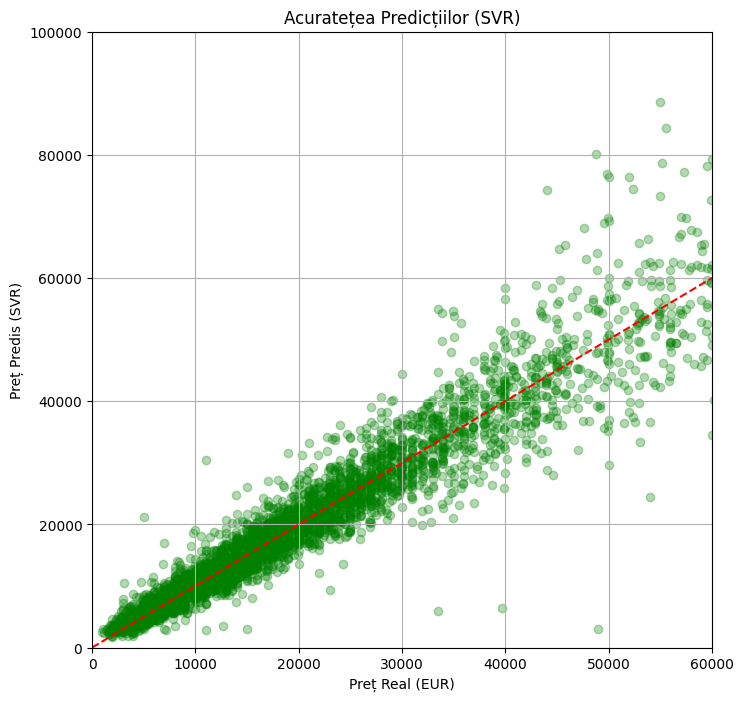

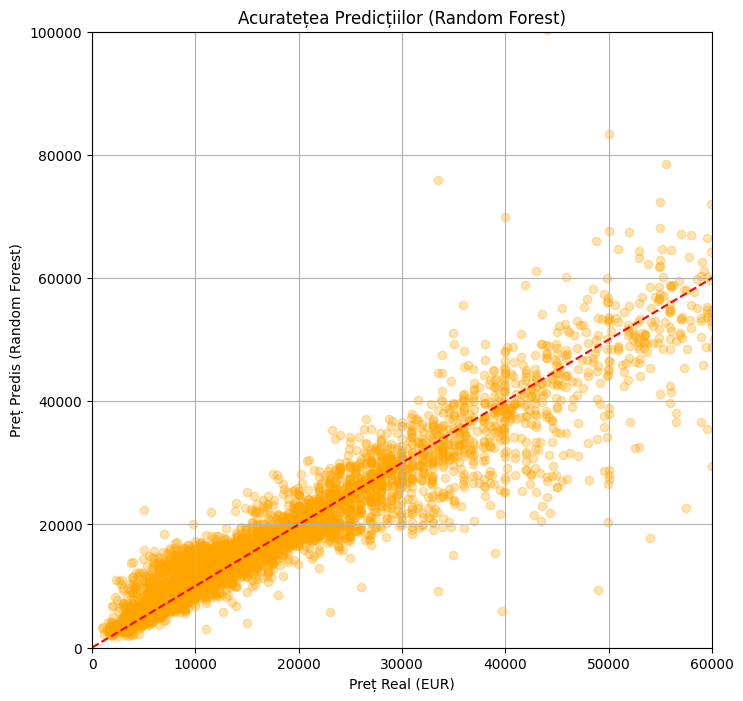

In [ ]:
feature_names = X_train_final.columns
if hasattr(best_gb, 'feature_importances_'):
    feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': best_gb.feature_importances_})
    feat_imp = feat_imp.sort_values('Importance', ascending=False).head(15)
    
    plt.figure(figsize=(8, 4))
    sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='magma')
    plt.title('Top 15 Factori de Preț (Gradient Boosting)')
    plt.show() 

final_comparison = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting (Standard)', 'GBR (Quantile - Median)', 'SVR'],
    'R2 Score (Mai mare e mai bun)': [r2, r2_gb, r2_gb_q, r2_svr],
    'MAE (Eroare - Mai mic e mai bun)': [mae, mae_gb, mae_gb_q, mae_svr],
    'RMSE': [rmse, rmse_gb, rmse_gb_q, rmse_svr]
})

final_comparison = final_comparison.sort_values(by='R2 Score (Mai mare e mai bun)', ascending=False).reset_index(drop=True)

print("\n============= CLASAMENT FINAL =============")
display(final_comparison)

plt.figure(figsize=(8, 8))
plt.scatter(y_val_real, y_pred_gb, alpha=0.3, color='blue')
plt.plot([0, 100000], [0, 100000], color='red', linestyle='--')
plt.xlabel('Preț Real (EUR)')
plt.ylabel('Preț Predis (Gradient Boosting)')
plt.title('Acuratețea Predicțiilor (Gradient Boosting)')
plt.xlim(0, 60000)
plt.ylim(0, 100000)
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 8))
plt.scatter(y_val_real, y_pred_med, alpha=0.3, color='purple')
plt.plot([0, 100000], [0, 100000], color='red', linestyle='--')
plt.xlabel('Preț Real (EUR)')
plt.ylabel('Preț Predis (GBR Median)')
plt.title('Acuratețea Predicțiilor (GBR - Cuantila Median)')
plt.xlim(0, 60000)
plt.ylim(0, 100000)
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 8))
plt.scatter(y_val_real, y_pred_svr, alpha=0.3, color='green')
plt.plot([0, 100000], [0, 100000], color='red', linestyle='--')
plt.xlabel('Preț Real (EUR)')
plt.ylabel('Preț Predis (SVR)')
plt.title('Acuratețea Predicțiilor (SVR)')
plt.xlim(0, 60000)
plt.ylim(0, 100000)
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 8))
plt.scatter(y_val_real, y_pred_final, alpha=0.3, color='orange')
plt.plot([0, 100000], [0, 100000], color='red', linestyle='--')
plt.xlabel('Preț Real (EUR)')
plt.ylabel('Preț Predis (Random Forest)')
plt.title('Acuratețea Predicțiilor (Random Forest)')
plt.xlim(0, 60000)
plt.ylim(0, 100000)
plt.grid(True)
plt.show()

In [ ]:
from sklearn.model_selection import cross_validate
import pandas as pd
import numpy as np
models_to_evaluate = {
    f"Random Forest\\n{best_rf_model.get_params()['n_estimators']} est, {best_rf_model.get_params()['max_depth']} depth": best_rf_model,
    
    f"Gradient Boosting\\n{best_gb.get_params()['n_estimators']} est, {best_gb.get_params()['learning_rate']} lr": best_gb,
    
    f"SVR\\n{best_svr.get_params()['kernel']}, C={best_svr.get_params()['C']}": best_svr,
    
    f"GBR Quantile (Median)\\nalpha=0.5": gbr_med
}

results_list = []

print("Se rulează Cross-Validation pentru tabelul final (poate dura)...")

for model_name, model in models_to_evaluate.items():
    scoring = {
        'r2': 'r2',
        'neg_mae': 'neg_mean_absolute_error',
        'neg_mse': 'neg_mean_squared_error'
    }
    
    cv_results = cross_validate(model, X_train_final, y_train, cv=5, scoring=scoring, n_jobs=-1)
    
    mean_r2 = cv_results['test_r2'].mean()
    std_r2 = cv_results['test_r2'].std()
    
    mean_mae = -cv_results['test_neg_mae'].mean()
    std_mae = cv_results['test_neg_mae'].std()
    
    mean_mse = -cv_results['test_neg_mse'].mean()
    std_mse = cv_results['test_neg_mse'].std()
    
    # RMSE
    mean_rmse = np.sqrt(mean_mse)
    
    results_list.append({
        "Model & Hiperparametri": model_name,
        "R2 (Mean ± Std)": f"{mean_r2:.3f} ± {std_r2:.3f}",
        "MAE (Mean ± Std)": f"{mean_mae:.3f} ± {std_mae:.3f}",
        "RMSE (Mean)": f"{mean_rmse:.3f}",
        "_r2_val": mean_r2,
        "_mae_val": mean_mae
    })

final_df = pd.DataFrame(results_list)

def highlight_best(data):
    best_r2_idx = data['_r2_val'].idxmax()
    best_mae_idx = data['_mae_val'].idxmin()
    
    styles = pd.DataFrame('', index=data.index, columns=data.columns)
    
    styles.loc[best_r2_idx, 'R2 (Mean ± Std)'] = 'font-weight: bold; background-color: #d1e7dd'
    styles.loc[best_mae_idx, 'MAE (Mean ± Std)'] = 'font-weight: bold; background-color: #d1e7dd'
    
    return styles

display_cols = ["Model & Hiperparametri", "R2 (Mean ± Std)", "MAE (Mean ± Std)", "RMSE (Mean)"]
styled_table = final_df.style.apply(highlight_best, axis=None).hide(subset=["_r2_val", "_mae_val"], axis=1)

print("\n=== TABEL CENTRALIZATOR ===")
display(styled_table)


Se rulează Cross-Validation pentru tabelul final (poate dura)...

=== TABEL CENTRALIZATOR (Conform Cerință 4.4) ===


,Model & Hiperparametri,R2 (Mean ± Std),MAE (Mean ± Std),RMSE (Mean)
0,"Random Forest\n300 est, 30 depth",0.959 ± 0.002,0.115 ± 0.005,0.176
1,"Gradient Boosting\n500 est, 0.05 lr",0.965 ± 0.003,0.109 ± 0.005,0.163
2,"SVR\nrbf, C=1",0.940 ± 0.003,0.147 ± 0.006,0.214
3,GBR Quantile (Median)\nalpha=0.5,0.962 ± 0.002,0.115 ± 0.005,0.170



Format Markdown pentru Raport:
| Model & Hiperparametri              | R2 (Mean ± Std)   | MAE (Mean ± Std)   |   RMSE (Mean) |
|:------------------------------------|:------------------|:-------------------|--------------:|
| Random Forest\n300 est, 30 depth    | 0.959 ± 0.002     | 0.115 ± 0.005      |         0.176 |
| Gradient Boosting\n500 est, 0.05 lr | 0.965 ± 0.003     | 0.109 ± 0.005      |         0.163 |
| SVR\nrbf, C=1                       | 0.940 ± 0.003     | 0.147 ± 0.006      |         0.214 |
| GBR Quantile (Median)\nalpha=0.5    | 0.962 ± 0.002     | 0.115 ± 0.005      |         0.17  |
